In [1]:
#This scripts trains and evaluates the individual models using the results of the Bayesian optimization.
#The script also produces the training data for the CALPHAD to D_max regression models

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from CBFV import composition
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import re
from ast import literal_eval
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from ax.service.ax_client import AxClient, ObjectiveProperties
from ax.core.arm import Arm

c:\Users\Chris\Documents\ML_Project\ML_GFA_env\Lib\site-packages\CBFV\composition.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
#establish the Flexible NN architecture and training/evaluation functions
#This is used for the non split CALPHAD Surrogate
class FlexibleNN(nn.Module):
    """
    A flexible neural network with configurable architecture for hyperparameter optimization.
    
    Parameters:
    -----------
    input_dim : int
        Number of input features (CBFV features)
    output_dim : int
        Number of output targets (phase fractions at selected temperatures)
    hidden_layers : list of int
        List of hidden layer sizes, e.g., [256, 128, 64]
    dropout_rate : float
        Dropout probability (0.0 to 1.0)
    dropout_type : str
        Type of dropout: 'standard', 'alpha' (for SELU), or 'none'
    activation : str
        Activation function: 'relu', 'leaky_relu', 'elu', 'selu', 'gelu', 'tanh'
    use_batch_norm : bool
        Whether to use batch normalization
    use_layer_norm : bool
        Whether to use layer normalization (alternative to batch norm)
    weight_decay : float
        L2 regularization strength (applied in optimizer, stored here for reference)
    nf_indices : list of int or None
        Indices of output columns that are phase fractions (NF). 
        These will have softmax applied so they sum to 1.
        If None, no softmax constraint is applied.
    output_columns : list of str or None
        Column names for outputs. If provided, NF columns are auto-detected
        by checking for 'NF_' prefix. Overrides nf_indices if both provided.
    """
    
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_layers=[256, 128, 64],
        dropout_rate=0.2,
        dropout_type='standard',
        activation='relu',
        use_batch_norm=False,
        use_layer_norm=False,
        weight_decay=0.0,
        nf_indices=None,
        output_columns=None
    ):
        super(FlexibleNN, self).__init__()
        
        self.weight_decay = weight_decay  # Store for optimizer configuration
        self.output_dim = output_dim
        
        # Determine NF indices (phase fractions that should sum to 1)
        if output_columns is not None:
            # Auto-detect NF columns from column names
            self.nf_indices = [i for i, col in enumerate(output_columns) if col.startswith('NF_')]
            self.df_indices = [i for i, col in enumerate(output_columns) if col.startswith('DF_')]
        elif nf_indices is not None:
            self.nf_indices = nf_indices
            self.df_indices = [i for i in range(output_dim) if i not in nf_indices]
        else:
            self.nf_indices = []
            self.df_indices = list(range(output_dim))
        
        # Build activation function
        activation_fn = self._get_activation(activation)
        
        # Build dropout layer
        dropout_layer = self._get_dropout(dropout_type, dropout_rate)
        
        # Build the network layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_layers:
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            # Normalization (batch norm or layer norm, not both)
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif use_layer_norm:
                layers.append(nn.LayerNorm(hidden_dim))
            
            # Activation
            layers.append(activation_fn())
            
            # Dropout
            if dropout_layer is not None:
                layers.append(dropout_layer(dropout_rate))
            
            prev_dim = hidden_dim
        
        # Output layer (no activation, dropout, or normalization)
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def _get_activation(self, activation):
        activations = {
            'relu': nn.ReLU,
            'leaky_relu': lambda: nn.LeakyReLU(0.1),
            'elu': nn.ELU,
            'selu': nn.SELU,
            'gelu': nn.GELU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid
        }
        if activation not in activations:
            raise ValueError(f"Unknown activation: {activation}. Choose from {list(activations.keys())}")
        return activations[activation]
    
    def _get_dropout(self, dropout_type, dropout_rate):
        if dropout_type == 'none' or dropout_rate == 0:
            return None
        elif dropout_type == 'standard':
            return nn.Dropout
        elif dropout_type == 'alpha':
            return nn.AlphaDropout  # For use with SELU activation
        else:
            raise ValueError(f"Unknown dropout type: {dropout_type}. Choose from ['standard', 'alpha', 'none']")
    
    def forward(self, x):
        raw_output = self.network(x)
        
        # If no NF indices, return raw output
        if len(self.nf_indices) == 0:
            return raw_output
        
        # Apply softmax to NF (phase fraction) outputs so they sum to 1
        output = raw_output.clone()
        
        # Extract NF outputs and apply softmax
        nf_outputs = raw_output[:, self.nf_indices]
        nf_normalized = torch.softmax(nf_outputs, dim=1)
        
        # Put normalized NF values back
        output[:, self.nf_indices] = nf_normalized
        
        return output
    
    def get_optimizer(self, optimizer_type='adam', lr=1e-3):
        """
        Get an optimizer with the configured weight decay (L2 regularization).
        """
        optimizers = {
            'adam': lambda: torch.optim.Adam(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'adamw': lambda: torch.optim.AdamW(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'sgd': lambda: torch.optim.SGD(self.parameters(), lr=lr, weight_decay=self.weight_decay, momentum=0.9),
            'rmsprop': lambda: torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=self.weight_decay)
        }
        if optimizer_type not in optimizers:
            raise ValueError(f"Unknown optimizer: {optimizer_type}. Choose from {list(optimizers.keys())}")
        return optimizers[optimizer_type]()


def train_epoch_FlexNN(model, train_loader, optimizer, criterion, device):
    """
    Train the model for one epoch.
    
    Returns:
    --------
    float : Average training loss for the epoch
    """
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


def evaluate_epoch_FlexNN(model, val_loader, criterion, device):
    """
    Evaluate the model on validation data.
    
    Returns:
    --------
    tuple : (average loss, predictions, targets)
    """
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            batch_size = X_batch.size(0)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            # Weight loss by batch size for correct averaging
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            
            all_predictions.append(predictions.cpu())
            all_targets.append(y_batch.cpu())
    
    # Weighted average loss (accounts for different batch sizes)
    avg_loss = total_loss / total_samples
    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    return avg_loss, all_predictions, all_targets


def train_model_FlexNN(
    model,
    X_train, y_train,
    X_val, y_val,
    epochs=100,
    batch_size=32,
    optimizer_type='adam',
    lr=1e-3,
    criterion=None,
    early_stopping_patience=None,
    verbose=True,
    device=None
):
    """
    Train the model for a specified number of epochs.
    
    Parameters:
    -----------
    model : FlexibleNN
        The neural network model
    X_train, y_train : array-like
        Training data
    X_val, y_val : array-like
        Validation data
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
    optimizer_type : str
        Type of optimizer ('adam', 'adamw', 'sgd', 'rmsprop')
    lr : float
        Learning rate
    criterion : nn.Module
        Loss function (default: MSELoss)
    early_stopping_patience : int or None
        Stop training if val loss doesn't improve for this many epochs
    verbose : bool
        Whether to print progress
    device : str or None
        Device to train on ('cuda', 'mps', 'cpu', or None for auto-detect)
    
    Returns:
    --------
    dict : Training history with train_losses, val_losses, best_epoch
    """
    # Auto-detect device
    if device is None:
        if torch.cuda.is_available():
            device = 'cuda'
        elif torch.backends.mps.is_available():
            device = 'mps'
        else:
            device = 'cpu'
    
    device = torch.device(device)
    model = model.to(device)
    
    # Default criterion
    if criterion is None:
        criterion = nn.MSELoss()
    
    # Convert data to tensors
    X_train_t = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_t = torch.FloatTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_t = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_t = torch.FloatTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Get optimizer
    optimizer = model.get_optimizer(optimizer_type=optimizer_type, lr=lr)
    
    # Training history
    history = {
        'train_losses': [],
        'val_losses': [],
        'best_epoch': 0,
        'best_val_loss': float('inf')
    }
    
    # Early stopping
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Train
        train_loss = train_epoch_FlexNN(model, train_loader, optimizer, criterion, device)
        
        # Evaluate
        val_loss, _, _ = evaluate_epoch_FlexNN(model, val_loader, criterion, device)
        
        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        
        # Track best model
        if val_loss < history['best_val_loss']:
            history['best_val_loss'] = val_loss
            history['best_epoch'] = epoch
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Verbose output
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
        
        # Early stopping
        if early_stopping_patience and patience_counter >= early_stopping_patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}. Best epoch: {history['best_epoch']+1}")
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history

In [3]:
#establish the custom NN for the split CALPHAD surrogate, which has a different architecture and loss function than the non split surrogate
class PhaseFractionNN(nn.Module):
    """
    Neural network for predicting phase fractions (NF) where outputs must sum to 1.
    Applies softmax to all outputs to ensure they represent valid phase fractions.
    
    Parameters:
    -----------
    input_dim : int
        Number of input features (CBFV features + temperature)
    output_dim : int
        Number of phases to predict
    hidden_layers : list of int
        List of hidden layer sizes, e.g., [256, 512, 1024]
    dropout_rate : float
        Dropout probability (0.0 to 1.0)
    dropout_type : str
        Type of dropout: 'standard', 'alpha' (for SELU), or 'none'
    activation : str
        Activation function: 'relu', 'leaky_relu', 'elu', 'selu', 'gelu', 'tanh'
    use_batch_norm : bool
        Whether to use batch normalization
    use_layer_norm : bool
        Whether to use layer normalization (alternative to batch norm)
    weight_decay : float
        L2 regularization strength (applied in optimizer, stored here for reference)
    """
    
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_layers=[256, 512, 1024],
        dropout_rate=0.2,
        dropout_type='standard',
        activation='relu',
        use_batch_norm=False,
        use_layer_norm=False,
        weight_decay=0.0,
    ):
        super(PhaseFractionNN, self).__init__()
        
        self.weight_decay = weight_decay
        self.output_dim = output_dim
        
        # Build activation function
        activation_fn = self._get_activation(activation)
        
        # Build dropout layer
        dropout_layer = self._get_dropout(dropout_type, dropout_rate)
        
        # Build the network layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_layers:
            # Linear layer
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            # Normalization (batch norm or layer norm, not both)
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif use_layer_norm:
                layers.append(nn.LayerNorm(hidden_dim))
            
            # Activation
            layers.append(activation_fn())
            
            # Dropout
            if dropout_layer is not None:
                layers.append(dropout_layer(dropout_rate))
            
            prev_dim = hidden_dim
        
        # Output layer (no activation here - softmax applied in forward)
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def _get_activation(self, activation):
        activations = {
            'relu': nn.ReLU,
            'leaky_relu': lambda: nn.LeakyReLU(0.1),
            'elu': nn.ELU,
            'selu': nn.SELU,
            'gelu': nn.GELU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid
        }
        if activation not in activations:
            raise ValueError(f"Unknown activation: {activation}. Choose from {list(activations.keys())}")
        return activations[activation]
    
    def _get_dropout(self, dropout_type, dropout_rate):
        if dropout_type == 'none' or dropout_rate == 0:
            return None
        elif dropout_type == 'standard':
            return nn.Dropout
        elif dropout_type == 'alpha':
            return nn.AlphaDropout  # For use with SELU activation
        else:
            raise ValueError(f"Unknown dropout type: {dropout_type}. Choose from ['standard', 'alpha', 'none']")
    
    def forward(self, x):
        """
        Forward pass with softmax applied to ensure outputs sum to 1.
        """
        logits = self.network(x)
        # Apply softmax so phase fractions sum to 1
        phase_fractions = torch.softmax(logits, dim=1)
        return phase_fractions
    
    def get_optimizer(self, optimizer_type='adam', lr=1e-3):
        """
        Get an optimizer with the configured weight decay (L2 regularization).
        """
        optimizers = {
            'adam': lambda: torch.optim.Adam(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'adamw': lambda: torch.optim.AdamW(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'sgd': lambda: torch.optim.SGD(self.parameters(), lr=lr, weight_decay=self.weight_decay, momentum=0.9),
            'rmsprop': lambda: torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=self.weight_decay)
        }
        if optimizer_type not in optimizers:
            raise ValueError(f"Unknown optimizer: {optimizer_type}. Choose from {list(optimizers.keys())}")
        return optimizers[optimizer_type]()





# Custom loss for phase fractions - can use KL divergence or cross-entropy style loss
class PhaseFractionLoss(nn.Module):
    """
    Loss function for phase fraction prediction.
    Combines MSE with optional KL divergence to encourage proper probability distributions.
    
    Parameters:
    -----------
    mse_weight : float
        Weight for MSE component (default: 1.0)
    kl_weight : float
        Weight for KL divergence component (default: 0.0)
        Set > 0 to encourage outputs to match target distribution shape
    """
    def __init__(self, mse_weight=1.0, kl_weight=0.0):
        super().__init__()
        self.mse_weight = mse_weight
        self.kl_weight = kl_weight
        self.mse = nn.MSELoss()
        self.kl = nn.KLDivLoss(reduction='batchmean')
    
    def forward(self, predictions, targets):
        # MSE loss
        mse_loss = self.mse(predictions, targets)
        
        if self.kl_weight > 0:
            # KL divergence (predictions should already be softmax output)
            # Add small epsilon to avoid log(0)
            eps = 1e-8
            log_preds = torch.log(predictions + eps)
            # Normalize targets to sum to 1 (they should already, but just in case)
            targets_norm = targets / (targets.sum(dim=1, keepdim=True) + eps)
            kl_loss = self.kl(log_preds, targets_norm)
            return self.mse_weight * mse_loss + self.kl_weight * kl_loss
        
        return mse_loss


class DrivingForceNN(nn.Module):
    """
    Neural network for predicting driving forces (DF).
    Outputs are unconstrained real values (no softmax).
    
    Parameters:
    -----------
    input_dim : int
        Number of input features (CBFV features + temperature)
    output_dim : int
        Number of driving force outputs to predict
    hidden_layers : list of int
        List of hidden layer sizes, e.g., [256, 512, 1024]
    dropout_rate : float
        Dropout probability (0.0 to 1.0)
    dropout_type : str
        Type of dropout: 'standard', 'alpha' (for SELU), or 'none'
    activation : str
        Activation function: 'relu', 'leaky_relu', 'elu', 'selu', 'gelu', 'tanh'
    use_batch_norm : bool
        Whether to use batch normalization
    use_layer_norm : bool
        Whether to use layer normalization (alternative to batch norm)
    weight_decay : float
        L2 regularization strength (applied in optimizer, stored here for reference)
    """
    
    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_layers=[256, 512, 1024],
        dropout_rate=0.2,
        dropout_type='standard',
        activation='relu',
        use_batch_norm=False,
        use_layer_norm=False,
        weight_decay=0.0,
    ):
        super(DrivingForceNN, self).__init__()
        
        self.weight_decay = weight_decay
        self.output_dim = output_dim
        
        # Build activation function
        activation_fn = self._get_activation(activation)
        
        # Build dropout layer
        dropout_layer = self._get_dropout(dropout_type, dropout_rate)
        
        # Build the network layers
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            elif use_layer_norm:
                layers.append(nn.LayerNorm(hidden_dim))
            
            layers.append(activation_fn())
            
            if dropout_layer is not None:
                layers.append(dropout_layer(dropout_rate))
            
            prev_dim = hidden_dim
        
        # Output layer - no activation (driving forces are unconstrained real values)
        layers.append(nn.Linear(prev_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def _get_activation(self, activation):
        activations = {
            'relu': nn.ReLU,
            'leaky_relu': lambda: nn.LeakyReLU(0.1),
            'elu': nn.ELU,
            'selu': nn.SELU,
            'gelu': nn.GELU,
            'tanh': nn.Tanh,
            'sigmoid': nn.Sigmoid
        }
        if activation not in activations:
            raise ValueError(f"Unknown activation: {activation}. Choose from {list(activations.keys())}")
        return activations[activation]
    
    def _get_dropout(self, dropout_type, dropout_rate):
        if dropout_type == 'none' or dropout_rate == 0:
            return None
        elif dropout_type == 'standard':
            return nn.Dropout
        elif dropout_type == 'alpha':
            return nn.AlphaDropout
        else:
            raise ValueError(f"Unknown dropout type: {dropout_type}. Choose from ['standard', 'alpha', 'none']")
    
    def forward(self, x):
        """
        Forward pass - raw output, no constraints applied.
        Driving forces can be any real value.
        """
        return self.network(x)
    
    def get_optimizer(self, optimizer_type='adam', lr=1e-3):
        """
        Get an optimizer with the configured weight decay (L2 regularization).
        """
        optimizers = {
            'adam': lambda: torch.optim.Adam(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'adamw': lambda: torch.optim.AdamW(self.parameters(), lr=lr, weight_decay=self.weight_decay),
            'sgd': lambda: torch.optim.SGD(self.parameters(), lr=lr, weight_decay=self.weight_decay, momentum=0.9),
            'rmsprop': lambda: torch.optim.RMSprop(self.parameters(), lr=lr, weight_decay=self.weight_decay)
        }
        if optimizer_type not in optimizers:
            raise ValueError(f"Unknown optimizer: {optimizer_type}. Choose from {list(optimizers.keys())}")
        return optimizers[optimizer_type]()

In [4]:
#define the fourier transform function used across all models to transform temperature into Fourier features
def fourier_features(T, n_freqs=6):
    """
    Generate Fourier features for temperature values.
    
    Args:
        T: 1D tensor of temperature values (shape: [N])
        n_freqs: number of frequency components (produces 2*n_freqs features)
    
    Returns:
        2D tensor of shape [N, 2*n_freqs] where each row is the Fourier encoding
    """
    # Ensure T is 2D with shape [N, 1] for broadcasting
    if T.dim() == 1:
        T = T.unsqueeze(1)
    
    feats = []
    for k in range(n_freqs):
        freq = 2**k
        feats.append(torch.sin(2 * torch.pi * freq * T))
        feats.append(torch.cos(2 * torch.pi * freq * T))
    
    # Stack along dim=1 to get shape [N, 2*n_freqs]
    return torch.cat(feats, dim=1)

In [5]:
#load the training data for the CALPHAD surrogate models
train_calphad_df = pd.read_csv(r'Data/F(T)_Data/calphad_alloys_train_opt_reshaped.csv')
train_calphad_df.head()

#load the test data for the CALPHAD surrogate models
test_calphad_df = pd.read_csv(r'Data/F(T)_Data/calphad_alloys_test_reshaped.csv')
test_calphad_df.head()

,alloy_string,temperature,DF_AG2CA,DF_AG3BE8,DF_AG3CA5,DF_AG3MG,DF_AG7CA2,DF_AG9CA2,DF_AGCA,DF_AGCA3,...,NF_YSI2_H,NF_YSI2_R,NF_ZINCBLENDE_B3,NF_ZR2SI,NF_ZR3SI,NF_ZR3SI2,NF_ZR5SI3,NF_ZR5SI4,NF_ZRSI,NF_ZRSI2
0,B22.00Co12.00Fe60.00Y6.00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B22.00Co12.00Fe60.00Y6.00,50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,B22.00Co12.00Fe60.00Y6.00,100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,B22.00Co12.00Fe60.00Y6.00,150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,B22.00Co12.00Fe60.00Y6.00,200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#Extract alloy strings and create formula dataframe for the training data
train_formula_df = pd.DataFrame({'formula': train_calphad_df['alloy_string']})
print(f"Formula dataframe shape: {train_formula_df.shape}")
train_formula_df.head()

#Extract alloy strings and create formula dataframe for the test data
test_formula_df = pd.DataFrame({'formula': test_calphad_df['alloy_string']})
print(f"Formula dataframe shape: {test_formula_df.shape}")
test_formula_df.head()


Formula dataframe shape: (44982, 1)
Formula dataframe shape: (4998, 1)


,formula
0,B22.00Co12.00Fe60.00Y6.00
1,B22.00Co12.00Fe60.00Y6.00
2,B22.00Co12.00Fe60.00Y6.00
3,B22.00Co12.00Fe60.00Y6.00
4,B22.00Co12.00Fe60.00Y6.00


In [7]:
# Generate Composition-Based Feature Vectors using CBFV
# CBFV expects 'formula' column and optionally a 'target' column
# Add a dummy target for featurization (we'll drop it after)
train_formula_df['target'] = 0
test_formula_df['target'] = 0


# Generate training CBFVs using the magpie element property database
X_train_CBFV, y_train_CBFV, formulae, skipped = composition.generate_features(train_formula_df, elem_prop='magpie')
print(f"CBFV features shape: {X_train_CBFV.shape}")
print(f"Number of skipped formulas: {len(skipped)}")
X_train_CBFV.head()

# Generate test CBFVs using the magpie element property database
X_test_CBFV, y_test_CBFV, formulae, skipped = composition.generate_features(test_formula_df, elem_prop='magpie')
print(f"CBFV features shape: {X_test_CBFV.shape}")
print(f"Number of skipped formulas: {len(skipped)}")
X_test_CBFV.head()


Processing Input Data: 100%|██████████| 44982/44982 [00:01<00:00, 40077.96it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 44982/44982 [00:01<00:00, 32212.93it/s]


	Creating Pandas Objects...
CBFV features shape: (44982, 132)
Number of skipped formulas: 0


Processing Input Data: 100%|██████████| 4998/4998 [00:00<00:00, 48494.11it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 4998/4998 [00:00<00:00, 33645.77it/s]

	Creating Pandas Objects...
CBFV features shape: (4998, 132)
Number of skipped formulas: 0


,avg_Number,avg_MendeleevNumber,avg_AtomicWeight,avg_MeltingT,avg_Column,avg_Row,avg_CovalentRadius,avg_Electronegativity,avg_NsValence,avg_NpValence,...,mode_NValence,mode_NsUnfilled,mode_NpUnfilled,mode_NdUnfilled,mode_NfUnfilled,mode_NUnfilled,mode_GSvolume_pa,mode_GSbandgap,mode_GSmagmom,mode_SpaceGroupNumber
0,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
1,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
2,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
3,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0
4,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,8.0,0.0,0.0,4.0,0.0,4.0,10.73,0.0,2.110663,229.0


In [8]:
#Perform the fourier transformation on the temperatures
fourier_Temp_features_train = fourier_features(torch.tensor(train_calphad_df['temperature'].values, dtype=torch.float32))
fourier_Temp_features_train_df = pd.DataFrame(
    fourier_Temp_features_train.numpy(),
    columns=[f'fourier_{i}' for i in range(fourier_Temp_features_train.shape[1])],
    index=train_calphad_df.index
)

#Perform the fourier transformation on the test temperatures
fourier_Temp_features_test = fourier_features(torch.tensor(test_calphad_df['temperature'].values, dtype=torch.float32))
fourier_Temp_features_test_df = pd.DataFrame(
    fourier_Temp_features_test.numpy(),
    columns=[f'fourier_{i}' for i in range(fourier_Temp_features_test.shape[1])],
    index=test_calphad_df.index
)

In [9]:
#Concat the feature dataframes to create X_train and X_test data for both data sets
X_Train_combined = pd.concat([X_train_CBFV, fourier_Temp_features_train_df], axis=1)
print(f"X shape: {X_Train_combined.shape}")
X_Train_combined.head()

X_Test_combined = pd.concat([X_test_CBFV, fourier_Temp_features_test_df], axis=1)
print(f"X shape: {X_Test_combined.shape}")
X_Test_combined.head()

X shape: (44982, 144)
X shape: (4998, 144)


,avg_Number,avg_MendeleevNumber,avg_AtomicWeight,avg_MeltingT,avg_Column,avg_Row,avg_CovalentRadius,avg_Electronegativity,avg_NsValence,avg_NpValence,...,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7,fourier_8,fourier_9,fourier_10,fourier_11
0,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,0.000000,1.0,0.000000,1.0,0.000000,1.0,0.000000,1.0,0.000000,1.000000
1,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,0.000012,1.0,0.000024,1.0,0.000047,1.0,0.000094,1.0,0.000188,1.000000
2,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,0.000024,1.0,0.000047,1.0,0.000094,1.0,0.000188,1.0,0.000376,1.000000
3,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,0.000096,1.0,0.000193,1.0,0.000385,1.0,0.000771,1.0,0.001541,0.999999
4,22.28,56.52,48.291754,1923.26,8.92,3.62,124.2,1.8456,2.0,0.22,...,0.000047,1.0,0.000094,1.0,0.000188,1.0,0.000376,1.0,0.000753,1.000000


In [10]:
#Create the y_train and y_test comprising of phase equilibrium information
y_train = train_calphad_df.drop(columns=['alloy_string', 'temperature'])
y_test = test_calphad_df.drop(columns=['alloy_string', 'temperature'])
print(f"Train phase information shape: {y_train.shape}")
print(f"Test phase information shape: {y_test.shape}")
y_train.head()

Train phase information shape: (44982, 1608)
Test phase information shape: (4998, 1608)


,DF_AG2CA,DF_AG3BE8,DF_AG3CA5,DF_AG3MG,DF_AG7CA2,DF_AG9CA2,DF_AGCA,DF_AGCA3,DF_AGCD_ETA,DF_AGIN2,...,NF_YSI2_H,NF_YSI2_R,NF_ZINCBLENDE_B3,NF_ZR2SI,NF_ZR3SI,NF_ZR3SI2,NF_ZR5SI3,NF_ZR5SI4,NF_ZRSI,NF_ZRSI2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
#detect and set training device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
#Begin evaluating the non split NN CALPHAD surrogate model, which predicts phase fractions at all temperatures in one model

#copy the data to avoid modifying the original
X_train_non_split_NN = X_Train_combined.copy()
y_train_non_split_NN = y_train.copy()

X_test_non_split_NN = X_Test_combined.copy()
y_test_non_split_NN = y_test.copy()

# Get input and output dimensions
input_dim_NN_ns = X_train_non_split_NN.shape[1]
output_dim_NN_ns = y_train_non_split_NN.shape[1]


#split to create a validation set for early stopping
X_train_NN_ns, X_val_NN_ns, y_train_NN_ns, y_val_NN_ns = train_test_split(X_train_non_split_NN, y_train_non_split_NN, test_size=0.2, random_state=42)

#Scale the X data 
scaler_ns = StandardScaler()
X_train_NN_ns_scaled = scaler_ns.fit_transform(X_train_NN_ns)
X_val_NN_ns_scaled = scaler_ns.transform(X_val_NN_ns)
X_test_NN_ns_scaled = scaler_ns.transform(X_test_non_split_NN)

#Scale the y data
scaler_y_ns = StandardScaler()
y_train_NN_ns_scaled = scaler_y_ns.fit_transform(y_train_NN_ns)
y_val_NN_ns_scaled = scaler_y_ns.transform(y_val_NN_ns)
y_test_NN_ns_scaled = scaler_y_ns.transform(y_test_non_split_NN)

#Convert all scaled data to tensors
X_train_NN_ns_tensor = torch.tensor(X_train_NN_ns_scaled, dtype=torch.float32)
y_train_NN_ns_tensor = torch.tensor(y_train_NN_ns_scaled, dtype=torch.float32)
X_val_NN_ns_tensor = torch.tensor(X_val_NN_ns_scaled, dtype=torch.float32)
y_val_NN_ns_tensor = torch.tensor(y_val_NN_ns_scaled, dtype=torch.float32)
X_test_NN_ns_tensor = torch.tensor(X_test_NN_ns_scaled, dtype=torch.float32)
y_test_NN_ns_tensor = torch.tensor(y_test_NN_ns_scaled, dtype=torch.float32)

#create tensor datasets and dataloaders for the non split surrogate
train_dataset_NN_ns = TensorDataset(X_train_NN_ns_tensor, y_train_NN_ns_tensor)
val_dataset_NN_ns = TensorDataset(X_val_NN_ns_tensor, y_val_NN_ns_tensor)
test_dataset_NN_ns = TensorDataset(X_test_NN_ns_tensor, y_test_NN_ns_tensor)

Best_parameters_NN_ns = {'dropout_rate': 0.2551544178277254, 'weight_decay': 9.945539915060379e-06, 'lr': 0.002343417645870794, 'optimizer_type': 'adamw', 'batch_size': 256, 'early_stopping_patience': 32, 'hidden_layers': [2048, 2048], 'activation': 'elu', 'normalization': 'layer_norm'}
#Best parameters: {'dropout_rate': 0.2551544178277254, 'weight_decay': 9.945539915060379e-06, 'lr': 0.002343417645870794, 'optimizer_type': 'adamw', 'batch_size': 256, 'early_stopping_patience': 32, 'architecture': 'constant_2048', 'activation': 'elu', 'normalization': 'layer_norm'}

# Create DataLoaders
# drop_last=True for train_loader to avoid batch size of 1 (causes BatchNorm to fail)
train_loader_NN_ns = DataLoader(train_dataset_NN_ns, batch_size=Best_parameters_NN_ns['batch_size'], shuffle=True, drop_last=True)
val_loader_NN_ns = DataLoader(val_dataset_NN_ns, batch_size=Best_parameters_NN_ns['batch_size'], shuffle=False)
test_loader_NN_ns = DataLoader(test_dataset_NN_ns, batch_size=Best_parameters_NN_ns['batch_size'], shuffle=False)

# Create the model with output_columns to auto-detect NF columns for softmax
model_NN_ns = FlexibleNN(
    input_dim=input_dim_NN_ns,
    output_dim=output_dim_NN_ns,
    hidden_layers=Best_parameters_NN_ns['hidden_layers'],
    dropout_rate=Best_parameters_NN_ns['dropout_rate'],
    dropout_type='standard',
    activation=Best_parameters_NN_ns['activation'],
    use_batch_norm=False,
    use_layer_norm=Best_parameters_NN_ns['normalization'] == 'layer_norm',
    weight_decay=Best_parameters_NN_ns['weight_decay'],
    output_columns=y_test_non_split_NN.columns.tolist()  # Auto-detect NF columns for softmax constraint
).to(device)


In [13]:
# Get optimizer and criterion
NN_ns_optimizer = model_NN_ns.get_optimizer(optimizer_type=Best_parameters_NN_ns['optimizer_type'], lr=Best_parameters_NN_ns['lr'])
NN_ns_criterion = nn.MSELoss()
NN_ns_epochs = 1000
NN_ns_early_stopping_patience = Best_parameters_NN_ns['early_stopping_patience']
NN_ns_verbose = True

# NN_ns Training loop
NN_ns_best_val_loss = float('inf')
NN_ns_best_model_state = None
NN_ns_patience_counter = 0
NN_ns_train_losses = []
NN_ns_val_losses = []


for epoch in range(NN_ns_epochs):
    # Train
    train_loss = train_epoch_FlexNN(model_NN_ns, train_loader_NN_ns, NN_ns_optimizer, NN_ns_criterion, device)
    
    # Evaluate on validation
    val_loss, _, _ = evaluate_epoch_FlexNN(model_NN_ns, val_loader_NN_ns, NN_ns_criterion, device)
    
    NN_ns_train_losses.append(train_loss)
    NN_ns_val_losses.append(val_loss)
    
    # Track best model
    if val_loss < NN_ns_best_val_loss:
        NN_ns_best_val_loss = val_loss
        NN_ns_best_model_state = {k: v.cpu().clone() for k, v in model_NN_ns.state_dict().items()}
        NN_ns_patience_counter = 0
    else:
        NN_ns_patience_counter += 1
    
    # Verbose output
    if NN_ns_verbose and (epoch % 20 == 0 or epoch == NN_ns_epochs - 1):
        print(f"Epoch {epoch+1}/{NN_ns_epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if NN_ns_early_stopping_patience and NN_ns_patience_counter >= NN_ns_early_stopping_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

    # Restore best model
    if NN_ns_best_model_state is not None:
        model_NN_ns.load_state_dict(NN_ns_best_model_state)
        model_NN_ns.to(device)

# Evaluate on test set (scaled)
NN_ns_test_loss_scaled, NN_ns_test_preds_scaled, NN_ns_test_targets_scaled = evaluate_epoch_FlexNN(model_NN_ns, test_loader_NN_ns, NN_ns_criterion, device)

# Inverse transform predictions and targets to original scale
NN_ns_test_preds_original = scaler_y_ns.inverse_transform(NN_ns_test_preds_scaled.numpy())
NN_ns_test_targets_original = scaler_y_ns.inverse_transform(NN_ns_test_targets_scaled.numpy())

# Get column indexes for separating DF (Driving Force) vs NF (Phase Fraction)
NN_ns_col_names = y_train_non_split_NN.columns.tolist()
df_cols = [i for i, col in enumerate(NN_ns_col_names) if col.startswith('DF_')]
nf_cols = [i for i, col in enumerate(NN_ns_col_names) if col.startswith('NF_')]

# Calculate overall RMSE and MAE on original scale (all values)
NN_ns_mse_original = np.mean((NN_ns_test_preds_original - NN_ns_test_targets_original) ** 2)
NN_ns_rmse = np.sqrt(NN_ns_mse_original)
NN_ns_mae = np.mean(np.abs(NN_ns_test_preds_original - NN_ns_test_targets_original))

# Calculate metrics for non-zero targets only
# Use a small threshold to handle floating point precision
nonzero_threshold = 1e-6

# Overall non-zero metrics
NN_ns_nonzero_mask = np.abs(NN_ns_test_targets_original) > nonzero_threshold
if np.any(NN_ns_nonzero_mask):
    nonzero_errors = NN_ns_test_preds_original[NN_ns_nonzero_mask] - NN_ns_test_targets_original[NN_ns_nonzero_mask]
    NN_ns_rmse_nonzero = np.sqrt(np.mean(nonzero_errors ** 2))
    NN_ns_mae_nonzero = np.mean(np.abs(nonzero_errors))
    NN_ns_n_nonzero = np.sum(NN_ns_nonzero_mask)
else:
    NN_ns_rmse_nonzero, NN_ns_mae_nonzero, NN_ns_n_nonzero = 0.0, 0.0, 0

# Calculate metrics for Driving Force columns (DF_) - non-zero only
if df_cols:
    df_preds = NN_ns_test_preds_original[:, df_cols]
    df_targets = NN_ns_test_targets_original[:, df_cols]
    df_nonzero_mask = np.abs(df_targets) > nonzero_threshold
    if np.any(df_nonzero_mask):
        df_errors = df_preds[df_nonzero_mask] - df_targets[df_nonzero_mask]
        NN_ns_df_rmse = np.sqrt(np.mean(df_errors ** 2))
        NN_ns_df_mae = np.mean(np.abs(df_errors))
        NN_ns_n_df_nonzero = np.sum(df_nonzero_mask)
    else:
        NN_ns_df_rmse, NN_ns_df_mae, NN_ns_n_df_nonzero = 0.0, 0.0, 0
else:
    NN_ns_df_rmse, NN_ns_df_mae, NN_ns_n_df_nonzero = 0.0, 0.0, 0

# Calculate metrics for Phase Fraction columns (NF_) - non-zero only
if nf_cols:
    nf_preds = NN_ns_test_preds_original[:, nf_cols]
    nf_targets = NN_ns_test_targets_original[:, nf_cols]
    nf_nonzero_mask = np.abs(nf_targets) > nonzero_threshold
    if np.any(nf_nonzero_mask):
        nf_errors = nf_preds[nf_nonzero_mask] - nf_targets[nf_nonzero_mask]
        NN_ns_nf_rmse = np.sqrt(np.mean(nf_errors ** 2))
        NN_ns_nf_mae = np.mean(np.abs(nf_errors))
        NN_ns_n_nf_nonzero = np.sum(nf_nonzero_mask)
    else:
        NN_ns_nf_rmse, NN_ns_nf_mae, NN_ns_n_nf_nonzero = 0.0, 0.0, 0
else:
    NN_ns_nf_rmse, NN_ns_nf_mae, NN_ns_n_nf_nonzero = 0.0, 0.0, 0

print(f"Overall (all)      - RMSE: {NN_ns_rmse:.4f}, MAE: {NN_ns_mae:.4f}")
print(f"Overall (non-zero) - RMSE: {NN_ns_rmse_nonzero:.4f}, MAE: {NN_ns_mae_nonzero:.4f}  [{NN_ns_n_nonzero:,} values]")
print(f"Driving Force (DF) - RMSE: {NN_ns_df_rmse:.4f}, MAE: {NN_ns_df_mae:.4f}  [{NN_ns_n_df_nonzero:,} non-zero values]")
print(f"Phase Fraction (NF) - RMSE: {NN_ns_nf_rmse:.4f}, MAE: {NN_ns_nf_mae:.4f}  [{NN_ns_n_nf_nonzero:,} non-zero values]")

Epoch 1/1000 - Train Loss: 0.525275 - Val Loss: 0.443785
Epoch 21/1000 - Train Loss: 0.364165 - Val Loss: 0.341967
Epoch 41/1000 - Train Loss: 0.358098 - Val Loss: 0.340161
Epoch 61/1000 - Train Loss: 0.357480 - Val Loss: 0.345669
Epoch 81/1000 - Train Loss: 0.346880 - Val Loss: 0.331458
Epoch 101/1000 - Train Loss: 0.345708 - Val Loss: 0.328635
Epoch 121/1000 - Train Loss: 0.335935 - Val Loss: 0.321718
Epoch 141/1000 - Train Loss: 0.333532 - Val Loss: 0.319204
Epoch 161/1000 - Train Loss: 0.333344 - Val Loss: 0.317713
Epoch 181/1000 - Train Loss: 0.333474 - Val Loss: 0.315478
Epoch 201/1000 - Train Loss: 0.332765 - Val Loss: 0.314434
Epoch 221/1000 - Train Loss: 0.331039 - Val Loss: 0.317312
Epoch 241/1000 - Train Loss: 0.331752 - Val Loss: 0.313541
Early stopping at epoch 255
Overall (all)      - RMSE: 1.0229, MAE: 0.1579
Overall (non-zero) - RMSE: 4.5139, MAE: 1.9736  [367,005 values]
Driving Force (DF) - RMSE: 4.5760, MAE: 2.0207  [357,053 non-zero values]
Phase Fraction (NF) - RMS

C:\Users\Chris\AppData\Local\Temp\ipykernel_20944\434556214.py:27: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.

c:\Users\Chris\Documents\ML_Project\ML_GFA_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



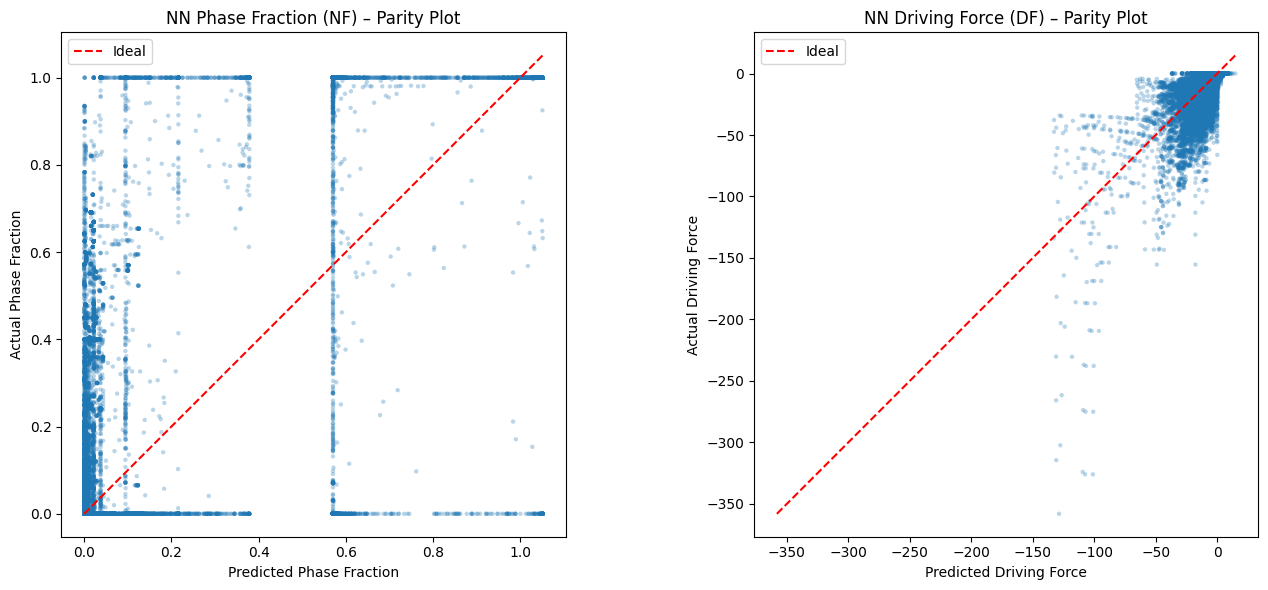

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Phase Fraction (NF) Parity Plot ---
ax = axes[0]
ax.scatter(nf_preds.flatten(), nf_targets.flatten(), alpha=0.3, s=10, edgecolors='none')
nf_min = min(nf_targets.min(), nf_preds.min())
nf_max = max(nf_targets.max(), nf_preds.max())
ax.plot([nf_min, nf_max], [nf_min, nf_max], 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('Predicted Phase Fraction')
ax.set_ylabel('Actual Phase Fraction')
ax.set_title('NN Phase Fraction (NF) – Parity Plot')
ax.legend()
ax.set_aspect('equal', adjustable='box')

# --- Driving Force (DF) Parity Plot ---
ax = axes[1]
ax.scatter(df_preds.flatten(), df_targets.flatten(), alpha=0.3, s=10, edgecolors='none')
df_min = min(df_targets.min(), df_preds.min())
df_max = max(df_targets.max(), df_preds.max())
ax.plot([df_min, df_max], [df_min, df_max], 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('Predicted Driving Force')
ax.set_ylabel('Actual Driving Force')
ax.set_title('NN Driving Force (DF) – Parity Plot')
ax.legend()
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [15]:
#Begin evaluating the non split XGB CALPHAD surrogate model

#copy the data to avoid modifying the original
X_train_XGB_ns = X_Train_combined.copy()
y_train_XGB_ns = y_train.copy()

X_test_XGB_ns = X_Test_combined.copy()
y_test_XGB_ns = y_test.copy()

#split the training data to create a validation set for early stopping
X_train_XGB_ns, X_val_XGB_ns, y_train_XGB_ns, y_val_XGB_ns = train_test_split(X_train_XGB_ns, y_train_XGB_ns, test_size=0.2, random_state=42)

# Scale the x data
scaler_x_XGB_ns = StandardScaler()
X_train_XGB_ns_scaled = pd.DataFrame(scaler_x_XGB_ns.fit_transform(X_train_XGB_ns), columns=X_train_XGB_ns.columns, index=X_train_XGB_ns.index)
X_val_XGB_ns_scaled = pd.DataFrame(scaler_x_XGB_ns.transform(X_val_XGB_ns), columns=X_val_XGB_ns.columns, index=X_val_XGB_ns.index)
X_test_XGB_ns_scaled = pd.DataFrame(scaler_x_XGB_ns.transform(X_test_XGB_ns), columns=X_test_XGB_ns.columns, index=X_test_XGB_ns.index)

#Best parameters for XGBRegressor (from ax optimization) V1 (Degraded performance - ax version error suspected rerunning opt with corrected ax version)
best_params_XGB_ns = {'n_estimators': 9856, 'max_depth': 25, 'learning_rate': 0.005797910076787395, 'subsample': 0.5037925727665424, 'colsample_bytree': 0.4406051756814122, 'min_child_weight': 11, 'reg_alpha': 0.0010842902645472655, 'reg_lambda': 0.0007034128402734389, 'gamma': 1.3193826703354716, 'early_stopping_rounds': 49}


# Train one XGBRegressor per output column (manual multi-output)
# This avoids the MultiOutputRegressor eval_set bug where full multi-column
# y_val is passed to each single-output estimator
estimators_XGB_ns = []
best_iters_XGB_ns = []
output_cols_XGB_ns = y_test_XGB_ns.columns.tolist()

for col_idx, col_name in enumerate(output_cols_XGB_ns):
    xgb_model = XGBRegressor(
        n_estimators=best_params_XGB_ns['n_estimators'],
        max_depth=best_params_XGB_ns['max_depth'],
        learning_rate=best_params_XGB_ns['learning_rate'],
        subsample=best_params_XGB_ns['subsample'],
        colsample_bytree=best_params_XGB_ns['colsample_bytree'],
        min_child_weight=best_params_XGB_ns['min_child_weight'],
        reg_alpha=best_params_XGB_ns['reg_alpha'],
        reg_lambda=best_params_XGB_ns['reg_lambda'],
        gamma=best_params_XGB_ns['gamma'],
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        early_stopping_rounds=best_params_XGB_ns['early_stopping_rounds'],
        eval_metric='rmse',
        device='cuda',
        tree_method='hist',
    )
    
    xgb_model.fit(
        X_train_XGB_ns_scaled, y_train_XGB_ns[col_name],
        eval_set=[(X_val_XGB_ns_scaled, y_val_XGB_ns[col_name])],
        verbose=False,
    )
    
    estimators_XGB_ns.append(xgb_model)
    best_iters_XGB_ns.append(xgb_model.best_iteration)


    print(f"Best iterations (min/mean/max): {min(best_iters_XGB_ns)}/{np.mean(best_iters_XGB_ns):.0f}/{max(best_iters_XGB_ns)}")

# Predict on test set (stack individual predictions)
test_preds_original = np.column_stack([
    est.predict(X_test_XGB_ns_scaled) for est in estimators_XGB_ns
])
test_targets_original = y_test_XGB_ns.values

# Calculate overall RMSE and MAE on original scale (all values)
mse_original = np.mean((test_preds_original - test_targets_original) ** 2)
rmse = np.sqrt(mse_original)
mae = np.mean(np.abs(test_preds_original - test_targets_original))

# Calculate metrics for non-zero targets only
nonzero_threshold = 1e-6

# Overall non-zero metrics
nonzero_mask = np.abs(test_targets_original) > nonzero_threshold
if np.any(nonzero_mask):
    nonzero_errors = test_preds_original[nonzero_mask] - test_targets_original[nonzero_mask]
    rmse_nonzero = np.sqrt(np.mean(nonzero_errors ** 2))
    mae_nonzero = np.mean(np.abs(nonzero_errors))
    n_nonzero = np.sum(nonzero_mask)
else:
    rmse_nonzero, mae_nonzero, n_nonzero = 0.0, 0.0, 0

# Calculate metrics for Driving Force columns (DF_) - non-zero only
if df_cols:
    df_preds = test_preds_original[:, df_cols]
    df_targets = test_targets_original[:, df_cols]
    df_nonzero_mask = np.abs(df_targets) > nonzero_threshold
    if np.any(df_nonzero_mask):
        df_errors = df_preds[df_nonzero_mask] - df_targets[df_nonzero_mask]
        df_rmse = np.sqrt(np.mean(df_errors ** 2))
        df_mae = np.mean(np.abs(df_errors))
        n_df_nonzero = np.sum(df_nonzero_mask)
    else:
        df_rmse, df_mae, n_df_nonzero = 0.0, 0.0, 0
else:
    df_rmse, df_mae, n_df_nonzero = 0.0, 0.0, 0

# Calculate metrics for Phase Fraction columns (NF_) - non-zero only
if nf_cols:
    nf_preds = test_preds_original[:, nf_cols]
    nf_targets = test_targets_original[:, nf_cols]
    nf_nonzero_mask = np.abs(nf_targets) > nonzero_threshold
    if np.any(nf_nonzero_mask):
        nf_errors = nf_preds[nf_nonzero_mask] - nf_targets[nf_nonzero_mask]
        nf_rmse = np.sqrt(np.mean(nf_errors ** 2))
        nf_mae = np.mean(np.abs(nf_errors))
        n_nf_nonzero = np.sum(nf_nonzero_mask)
    else:
        nf_rmse, nf_mae, n_nf_nonzero = 0.0, 0.0, 0
else:
    nf_rmse, nf_mae, n_nf_nonzero = 0.0, 0.0, 0

print(f"Overall (all)      - RMSE: {rmse:.4f}, MAE: {mae:.4f}")
print(f"Overall (non-zero) - RMSE: {rmse_nonzero:.4f}, MAE: {mae_nonzero:.4f}  [{n_nonzero:,} values]")
print(f"Driving Force (DF) - RMSE: {df_rmse:.4f}, MAE: {df_mae:.4f}  [{n_df_nonzero:,} non-zero values]")
print(f"Phase Fraction (NF) - RMSE: {nf_rmse:.4f}, MAE: {nf_mae:.4f}  [{n_nf_nonzero:,} non-zero values]")

Best iterations (min/mean/max): 547/547/547
Best iterations (min/mean/max): 547/618/690
Best iterations (min/mean/max): 547/848/1308
Best iterations (min/mean/max): 547/1046/1641
Best iterations (min/mean/max): 469/931/1641
Best iterations (min/mean/max): 466/854/1641
Best iterations (min/mean/max): 466/903/1641
Best iterations (min/mean/max): 466/936/1641
Best iterations (min/mean/max): 466/981/1641
Best iterations (min/mean/max): 466/936/1641
Best iterations (min/mean/max): 466/947/1641
Best iterations (min/mean/max): 466/1016/1774
Best iterations (min/mean/max): 466/1052/1774
Best iterations (min/mean/max): 466/1033/1774
Best iterations (min/mean/max): 466/1059/1774
Best iterations (min/mean/max): 466/1055/1774
Best iterations (min/mean/max): 466/1035/1774
Best iterations (min/mean/max): 466/1022/1774
Best iterations (min/mean/max): 466/1015/1774
Best iterations (min/mean/max): 466/1068/2069
Best iterations (min/mean/max): 466/1061/2069
Best iterations (min/mean/max): 466/1052/2069


KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Phase Fraction (NF) Parity Plot ---
ax = axes[0]
ax.scatter(nf_preds.flatten(), nf_targets.flatten(), alpha=0.3, s=10, edgecolors='none')
nf_min = min(nf_targets.min(), nf_preds.min())
nf_max = max(nf_targets.max(), nf_preds.max())
ax.plot([nf_min, nf_max], [nf_min, nf_max], 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('Predicted Phase Fraction')
ax.set_ylabel('Actual Phase Fraction')
ax.set_title('XGB Phase Fraction (NF) – Parity Plot')
ax.legend()
ax.set_aspect('equal', adjustable='box')

# --- Driving Force (DF) Parity Plot ---
ax = axes[1]
ax.scatter(df_preds.flatten(), df_targets.flatten(), alpha=0.3, s=10, edgecolors='none')
df_min = min(df_targets.min(), df_preds.min())
df_max = max(df_targets.max(), df_preds.max())
ax.plot([df_min, df_max], [df_min, df_max], 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('Predicted Driving Force')
ax.set_ylabel('Actual Driving Force')
ax.set_title('XGB Driving Force (DF) – Parity Plot')
ax.legend()
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [ ]:
#Evaluation of split surrogate models - separate NN for phase fractions and driving forces


#Best parameters for NN NF surrogate (from ax optimization)
best_params_NN_NF = {'dropout_type': 'standard','dropout_rate': 0.0, 'weight_decay': 0.01, 'lr': 1e-05, 'optimizer_type': 'adam', 'batch_size': 32, 'early_stopping_patience': 29, 'hidden_layers': [2048, 2048], 'activation': 'leaky_relu', 'normalization': 'layer_norm'}



#copy the data to avoid modifying the original
X_train_NN_split = X_Train_combined.copy()
y_train_NN_split = y_train.copy()

X_test_NN_split = X_Test_combined.copy()
y_test_NN_split = y_test.copy()

#sepearte the NF and DF columns for the split surrogate models
all_col_names_NN_split = y_train_NN_split.columns.tolist()
df_cols_names = [col for col in all_col_names_NN_split if col.startswith('DF_')]
nf_cols_names  = [col for col in all_col_names_NN_split if col.startswith('NF_')]


#create the different split y data for nf and df sets using names not indexes to avoid any indexing errors
y_train_NN_nf = y_train_NN_split[nf_cols_names]
y_test_NN_nf = y_test_NN_split[nf_cols_names]
y_train_NN_DF = y_train_NN_split[df_cols_names]
y_test_NN_DF = y_test_NN_split[df_cols_names]

#seperate the x data into nf and df sets for the split surrogate models - use names not indexes to avoid any indexing errors
X_train_NN_nf = X_train_NN_split.copy()[nf_cols_names]
X_test_NN_nf = X_test_NN_split.copy()[nf_cols_names]
X_train_NN_DF = X_train_NN_split.copy()[df_cols_names]
X_test_NN_DF = X_test_NN_split.copy()[df_cols_names]

print(f"Phase Fractions (NF) train shape: {y_train_NN_nf.shape}, test shape: {y_test_NN_nf.shape}")
print(f"Driving Forces (DF) train shape: {y_train_NN_DF.shape}, test shape: {y_test_NN_DF.shape}")
print(f"\nNF columns: {len(nf_cols_names)}, DF columns: {len(df_cols_names)}")

#Begin with the evaluation of the NN NF surrogate model

# Get input and output dimensions
input_dim_NN_NF = X_train_NN_nf.shape[1]
output_dim_NN_NF = y_train_NN_nf.shape[1]
print(f"Input dim: {input_dim_NN_NF}, Output dim: {output_dim_NN_NF}")

#create the valadation split for the NN NF surrogate
X_train_NN_NF, X_val_NN_NF, y_train_NN_NF, y_val_NN_NF = train_test_split(X_train_NN_nf, y_train_NN_nf, test_size=0.2, random_state=42)
print(f"Train: {len(X_train_NN_NF)}, Val: {len(X_val_NN_NF)}, Test: {len(X_test_NN_nf)}")


#Scale the X data
scaler_X_NN_NF = StandardScaler()
X_train_NN_NF_scaled = scaler_X_NN_NF.fit_transform(X_train_NN_NF)
X_val_NN_NF_scaled = scaler_X_NN_NF.transform(X_val_NN_NF)
X_test_NN_NF_scaled = scaler_X_NN_NF.transform(X_test_NN_nf)

#Scale the y data
scaler_y_NN_NF = StandardScaler()
y_train_NN_NF_scaled = scaler_y_NN_NF.fit_transform(y_train_NN_NF)
y_val_NN_NF_scaled = scaler_y_NN_NF.transform(y_val_NN_NF)
y_test_NN_NF_scaled = scaler_y_NN_NF.transform(y_test_NN_nf)   

#Convert all scaled data to tensors
X_train_NN_NF_tensor = torch.tensor(X_train_NN_NF_scaled, dtype=torch.float32)
y_train_NN_NF_tensor = torch.tensor(y_train_NN_NF_scaled, dtype=torch.float32)
X_val_NN_NF_tensor = torch.tensor(X_val_NN_NF_scaled, dtype=torch.float32)
y_val_NN_NF_tensor = torch.tensor(y_val_NN_NF_scaled, dtype=torch.float32)
X_test_NN_NF_tensor = torch.tensor(X_test_NN_NF_scaled, dtype=torch.float32)
y_test_NN_NF_tensor = torch.tensor(y_test_NN_NF_scaled, dtype=torch.float32)

#create tensor datasets and dataloaders for the NN NF surrogate
train_dataset_NN_NF = TensorDataset(X_train_NN_NF_tensor, y_train_NN_NF_tensor)
val_dataset_NN_NF = TensorDataset(X_val_NN_NF_tensor, y_val_NN_NF_tensor)
test_dataset_NN_NF = TensorDataset(X_test_NN_NF_tensor, y_test_NN_NF_tensor)

train_dataloader_NN_NF = DataLoader(train_dataset_NN_NF, batch_size=best_params_NN_NF['batch_size'], shuffle=True, drop_last=True)
val_dataloader_NN_NF = DataLoader(val_dataset_NN_NF, batch_size=best_params_NN_NF['batch_size'], shuffle=False)
test_dataloader_NN_NF = DataLoader(test_dataset_NN_NF, batch_size=best_params_NN_NF['batch_size'], shuffle=False)


# Create the NN NF surrogate model V1 used the flexibleNN possible reopt with a phase fraction specific architecture with softmax output
model_NN_NF = FlexibleNN(
    input_dim=input_dim_NN_NF,
    output_dim=output_dim_NN_NF,
    hidden_layers=best_params_NN_NF["hidden_layers"],
    dropout_rate=best_params_NN_NF["dropout_rate"],
    dropout_type=best_params_NN_NF["dropout_type"],
    activation=best_params_NN_NF["activation"],
    use_batch_norm=best_params_NN_NF["normalization"] == 'batch_norm',
    use_layer_norm=best_params_NN_NF['normalization'] == 'layer_norm',
    weight_decay=best_params_NN_NF['weight_decay'],
    output_columns=nf_cols_names  # Auto-detect NF columns for softmax constraint
).to(device)


# Get optimizer and criterion
optimizer_NN_NF = model_NN_NF.get_optimizer(optimizer_type=best_params_NN_NF['optimizer_type'], lr=best_params_NN_NF['lr'])
criterion_NN_NF = nn.MSELoss()

# Training loop
best_val_loss_NN_NF = float('inf')
best_model_state_NN_NF = None
patience_counter_NN_NF = 0
train_losses_NN_NF = []
val_losses_NN_NF = []

for epoch in range(1000):
    # Train
    train_loss = train_epoch_FlexNN(model_NN_NF, train_dataloader_NN_NF, optimizer_NN_NF, criterion_NN_NF, device)
    
    # Evaluate on validation
    val_loss, _, _ = evaluate_epoch_FlexNN(model_NN_NF, val_dataloader_NN_NF, criterion_NN_NF, device)
    
    train_losses_NN_NF.append(train_loss)
    val_losses_NN_NF.append(val_loss)
    
    # Track best model
    if val_loss < best_val_loss_NN_NF:
        best_val_loss_NN_NF = val_loss
        best_model_state_NN_NF = {k: v.cpu().clone() for k, v in model_NN_NF.state_dict().items()}
        patience_counter_NN_NF = 0
    else:
        patience_counter_NN_NF += 1
    
    # Verbose output
    if (epoch % 20 == 0 or epoch == 1000 - 1):
        print(f"Epoch {epoch+1}/1000 - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if patience_counter_NN_NF >= best_params_NN_NF['early_stopping_patience']:
        print(f"Early stopping at epoch {epoch+1}")
        break


# Restore best model
if best_model_state_NN_NF is not None:
    model_NN_NF.load_state_dict(best_model_state_NN_NF)
    model_NN_NF.to(device)

# Evaluate on test set (scaled)
test_loss_scaled_NN_NF, test_preds_scaled_NN_NF, test_targets_scaled_NN_NF = evaluate_epoch_FlexNN(model_NN_NF, test_dataloader_NN_NF, criterion_NN_NF, device)

# Inverse transform predictions and targets to original scale
test_preds_original_NN_NF = scaler_y_NN_NF.inverse_transform(test_preds_scaled_NN_NF.numpy())
test_targets_original_NN_NF = scaler_y_NN_NF.inverse_transform(test_targets_scaled_NN_NF.numpy())

# Calculate overall RMSE and MAE on original scale (all values)
mse_original_NN_NF = np.mean((test_preds_original_NN_NF - test_targets_original_NN_NF) ** 2)
rmse_NN_NF = np.sqrt(mse_original_NN_NF)
mae_NN_NF = np.mean(np.abs(test_preds_original_NN_NF - test_targets_original_NN_NF))

# Calculate metrics for non-zero targets only
# Use a small threshold to handle floating point precision
nonzero_threshold = 1e-6

# Overall non-zero metrics
nonzero_mask = np.abs(test_targets_original_NN_NF) > nonzero_threshold
if np.any(nonzero_mask):
    nonzero_errors = test_preds_original_NN_NF[nonzero_mask] - test_targets_original_NN_NF[nonzero_mask]
    rmse_nonzero = np.sqrt(np.mean(nonzero_errors ** 2))
    mae_nonzero = np.mean(np.abs(nonzero_errors))
    n_nonzero = np.sum(nonzero_mask)
else:
    rmse_nonzero, mae_nonzero, n_nonzero = 0.0, 0.0, 0

# Calculate metrics for Phase Fraction columns (NF_) - non-zero only
nf_nonzero_mask = np.abs(test_targets_original_NN_NF) > nonzero_threshold
if np.any(nf_nonzero_mask):
    nf_errors = test_preds_original_NN_NF[nf_nonzero_mask] - test_targets_original_NN_NF[nf_nonzero_mask]
    nf_rmse = np.sqrt(np.mean(nf_errors ** 2))
    nf_mae = np.mean(np.abs(nf_errors))
    n_nf_nonzero = np.sum(nf_nonzero_mask)
else:
    nf_rmse, nf_mae, n_nf_nonzero = 0.0, 0.0, 0

print(f"Overall (all)      - RMSE: {rmse_NN_NF:.4f}, MAE: {mae_NN_NF:.4f}")
print(f"Overall (non-zero) - RMSE: {rmse_nonzero:.4f}, MAE: {mae_nonzero:.4f}  [{n_nonzero:,} values]")
print(f"Phase Fraction (NF) - RMSE: {nf_rmse:.4f}, MAE: {nf_mae:.4f}  [{n_nf_nonzero:,} non-zero values]")

Phase Fractions (NF) train shape: (44982, 804), test shape: (4998, 804)
Driving Forces (DF) train shape: (44982, 804), test shape: (4998, 804)

NF columns: 804, DF columns: 804
Input dim: 144, Output dim: 804
Train: 35985, Val: 8997, Test: 4998
Epoch 1/1000 - Train Loss: 0.312251 - Val Loss: 0.322640
Epoch 21/1000 - Train Loss: 0.312316 - Val Loss: 0.322639
Early stopping at epoch 32
Overall (all)      - RMSE: 0.0260, MAE: 0.0025
Overall (non-zero) - RMSE: 0.4289, MAE: 0.3372  [9,952 values]
Phase Fraction (NF) - RMSE: 0.4289, MAE: 0.3372  [9,952 non-zero values]


In [ ]:
#evaluate the best nn df surrogate model using the same process as above but with the df columns and data
# Extract hyperparameters from parameters dict with defaults
best_parameters_NN_DF = {'dropout_rate': 0.0, 'weight_decay': 0.01, 'lr': 1e-05, 'optimizer_type': 'adam', 'batch_size': 32, 'early_stopping_patience': 29, 'architecture': 'constant_2048', 'activation': 'leaky_relu', 'normalization': 'layer_norm'}

batch_size = best_parameters_NN_DF['batch_size']
hidden_layers = best_parameters_NN_DF['hidden_layers']
dropout_rate = best_parameters_NN_DF['dropout_rate']
dropout_type = best_parameters_NN_DF['dropout_type']
activation = best_parameters_NN_DF['activation']
use_batch_norm = best_parameters_NN_DF['use_batch_norm']
use_layer_norm = best_parameters_NN_DF['use_layer_norm']
weight_decay = best_parameters_NN_DF['weight_decay']
optimizer_type = best_parameters_NN_DF['optimizer_type']
lr = best_parameters_NN_DF['lr']
early_stopping_patience = best_parameters_NN_DF['early_stopping_patience']

# Auto-detect device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

\

# Get input and output dimensions
input_dim = X_train_NN_DF.shape[1]
output_dim = y_train_NN_DF.shape[1]
print(f"Input dim: {input_dim}, Output dim: {output_dim}")


# Create train and validation data
X_train_NN_DF, X_val_NN_DF, y_train_NN_DF, y_val_NN_DF = train_test_split(
    X_train_NN_DF, y_train_NN_DF, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train_NN_DF)}, Val: {len(X_val_NN_DF)}, Test: {len(X_test_NN_DF)}")

# Scale the x data
scaler_X_NN_DF = StandardScaler()
X_train_scaled_NN_DF = pd.DataFrame(scaler_X_NN_DF.fit_transform(X_train_NN_DF), columns=X_train_NN_DF.columns, index=X_train_NN_DF.index)
X_val_scaled_NN_DF = pd.DataFrame(scaler_X_NN_DF.transform(X_val_NN_DF), columns=X_val_NN_DF.columns, index=X_val_NN_DF.index)
X_test_scaled_NN_DF = pd.DataFrame(scaler_X_NN_DF.transform(X_test_NN_DF), columns=X_test_NN_DF.columns, index=X_test_NN_DF.index)

# Scale the y data
scaler_y_NN_DF = StandardScaler()
y_train_scaled_NN_DF = pd.DataFrame(scaler_y_NN_DF.fit_transform(y_train_NN_DF), columns=y_train_NN_DF.columns, index=y_train_NN_DF.index)
y_val_scaled_NN_DF = pd.DataFrame(scaler_y_NN_DF.transform(y_val_NN_DF), columns=y_val_NN_DF.columns, index=y_val_NN_DF.index)
y_test_scaled_NN_DF = pd.DataFrame(scaler_y_NN_DF.transform(y_test_NN_DF), columns=y_test_NN_DF.columns, index=y_test_NN_DF.index)

# Convert DataFrames to PyTorch tensors
X_train_NN_DF_t = torch.FloatTensor(X_train_scaled_NN_DF.values)
y_train_NN_DF_t = torch.FloatTensor(y_train_scaled_NN_DF.values)
X_val_NN_DF_t = torch.FloatTensor(X_val_scaled_NN_DF.values)
y_val_NN_DF_t = torch.FloatTensor(y_val_scaled_NN_DF.values)
X_test_NN_DF_t = torch.FloatTensor(X_test_scaled_NN_DF.values)
y_test_NN_DF_t = torch.FloatTensor(y_test_scaled_NN_DF.values)

# Create TensorDatasets
train_dataset_NN_DF = TensorDataset(X_train_NN_DF_t, y_train_NN_DF_t)
val_dataset_NN_DF = TensorDataset(X_val_NN_DF_t, y_val_NN_DF_t)
test_dataset_NN_DF = TensorDataset(X_test_NN_DF_t, y_test_NN_DF_t)

# Create DataLoaders
# drop_last=True for train_loader to avoid batch size of 1 (causes BatchNorm to fail)
train_loader_NN_DF = DataLoader(train_dataset_NN_DF, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader_NN_DF = DataLoader(val_dataset_NN_DF, batch_size=batch_size, shuffle=False)
test_loader_NN_DF = DataLoader(test_dataset_NN_DF, batch_size=batch_size, shuffle=False)

# Create the DrivingForceNN model (no softmax — outputs are unconstrained real values)
model_NN_DF = DrivingForceNN(
    input_dim=input_dim,
    output_dim=output_dim,
    hidden_layers=hidden_layers,
    dropout_rate=dropout_rate,
    dropout_type=dropout_type,
    activation=activation,
    use_batch_norm=use_batch_norm,
    use_layer_norm=use_layer_norm,
    weight_decay=weight_decay,
).to(device)

# Get optimizer and criterion
optimizer_NN_DF = model_NN_DF.get_optimizer(optimizer_type=optimizer_type, lr=lr)
criterion_NN_DF = nn.MSELoss()

# Training loop
best_val_loss_NN_DF = float('inf')
best_model_state_NN_DF = None
patience_counter_NN_DF = 0
train_losses_NN_DF = []
val_losses_NN_DF = []

for epoch in range(1000):
    # Train
    train_loss = train_epoch_FlexNN(model_NN_DF, train_loader_NN_DF, optimizer_NN_DF, criterion_NN_DF, device)
    
    # Evaluate on validation
    val_loss, _, _ = evaluate_epoch_FlexNN(model_NN_DF, val_loader_NN_DF, criterion_NN_DF, device)
    
    train_losses_NN_DF.append(train_loss)
    val_losses_NN_DF.append(val_loss)
    
    # Track best model
    if val_loss < best_val_loss_NN_DF:
        best_val_loss_NN_DF = val_loss
        best_model_state_NN_DF = {k: v.cpu().clone() for k, v in model_NN_DF.state_dict().items()}
        patience_counter_NN_DF = 0
    else:
        patience_counter_NN_DF += 1
    
    # Verbose output
    if True and (epoch % 20 == 0 or epoch == 100 - 1):
        print(f"Epoch {epoch+1}/{1000} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if early_stopping_patience and patience_counter_NN_DF >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Restore best model
if best_model_state_NN_DF is not None:
    model_NN_DF.load_state_dict(best_model_state_NN_DF)
    model_NN_DF.to(device)

# Evaluate on test set (scaled)
test_loss_scaled_NN_DF, test_preds_scaled_NN_DF, test_targets_scaled_NN_DF = evaluate_epoch_FlexNN(model_NN_DF, test_loader_NN_DF, criterion_NN_DF, device)

# Inverse transform predictions and targets to original scale
test_preds_original_NN_DF = scaler_y_NN_DF.inverse_transform(test_preds_scaled_NN_DF.numpy())
test_targets_original_NN_DF = scaler_y_NN_DF.inverse_transform(test_targets_scaled_NN_DF.numpy())

# Calculate overall RMSE and MAE on original scale (all values)
mse_original_NN_DF = np.mean((test_preds_original_NN_DF - test_targets_original_NN_DF) ** 2)
rmse_NN_DF = np.sqrt(mse_original_NN_DF)
mae_NN_DF = np.mean(np.abs(test_preds_original_NN_DF - test_targets_original_NN_DF))

# Calculate metrics for non-zero targets only
nonzero_threshold = 1e-6

nonzero_mask_NN_DF = np.abs(test_targets_original_NN_DF) > nonzero_threshold
if np.any(nonzero_mask_NN_DF):
    nonzero_errors = test_preds_original_NN_DF[nonzero_mask_NN_DF] - test_targets_original_NN_DF[nonzero_mask_NN_DF]
    rmse_nonzero_NN_DF = np.sqrt(np.mean(nonzero_errors ** 2))
    mae_nonzero_NN_DF = np.mean(np.abs(nonzero_errors))
    n_nonzero_NN_DF = np.sum(nonzero_mask_NN_DF)
else:
    rmse_nonzero_NN_DF, mae_nonzero_NN_DF, n_nonzero_NN_DF = 0.0, 0.0, 0

# Per-column RMSE for driving force outputs (non-zero only)
col_names_n = y_train_NN_DF.columns.tolist()
per_col_rmse_NN_DF = {}
for ci, col in enumerate(col_names_n):
    col_mask = np.abs(test_targets_original_NN_DF[:, ci]) > nonzero_threshold
    if np.any(col_mask):
        col_errors = test_preds_original_NN_DF[:, ci][col_mask] - test_targets_original_NN_DF[:, ci][col_mask]
        per_col_rmse_NN_DF[col] = np.sqrt(np.mean(col_errors ** 2))

print(f"Driving Force (all)      - RMSE: {rmse_NN_DF:.4f}, MAE: {mae_NN_DF:.4f}")
print(f"Driving Force (non-zero) - RMSE: {rmse_nonzero_NN_DF:.4f}, MAE: {mae_nonzero_NN_DF:.4f}  [{n_nonzero_NN_DF:,} values]")
